### 데이터시각화   
- 우선 노이즈가 추가되지 않은 원본 데이터로 시각화   

- 참고자료
- [데이터 EDA, 전처리](https://datananalysis.tistory.com/71) 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv("./credit_risk_dataset.csv") 
df.head() 

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


#### X 데이터에 노이즈 추가하기 

#### target Y의 클래스 별 퍼센트 나타내기 

In [4]:
grade_counts = df['loan_grade'].value_counts()
grade_counts

loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

In [5]:
grade_idx = grade_counts.index
print(grade_idx)

Index(['A', 'B', 'C', 'D', 'E', 'F', 'G'], dtype='object', name='loan_grade')


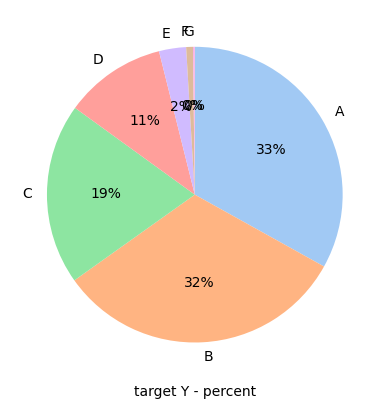

In [6]:
plt.pie(grade_counts, labels=grade_idx, autopct = '%d%%', startangle=90, counterclock=False, colors=sns.color_palette('pastel'))
plt.xlabel('target Y - percent')
plt.show()

#### X변수 중에 object type인거 percent 나타내기 

In [7]:
df.select_dtypes('object').head()

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
0,RENT,PERSONAL,D,Y
1,OWN,EDUCATION,B,N
2,MORTGAGE,MEDICAL,C,N
3,RENT,MEDICAL,C,N
4,RENT,MEDICAL,C,Y


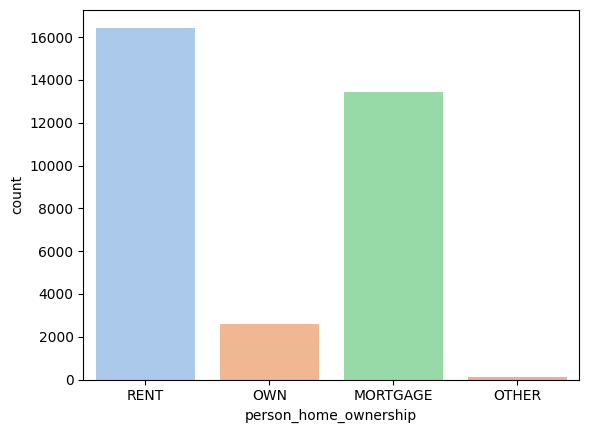

In [8]:
sns.countplot(data=df, x='person_home_ownership', hue = 'person_home_ownership', palette='pastel')
plt.show()

In [71]:
# sns.countplot(data=df, x='loan_intent', hue = 'loan_intent', palette='pastel')
# plt.xticks(rotation=45)
# plt.show()

In [72]:
# sns.countplot(data=df, x='cb_person_default_on_file', hue = 'cb_person_default_on_file', palette='pastel')
# plt.show()

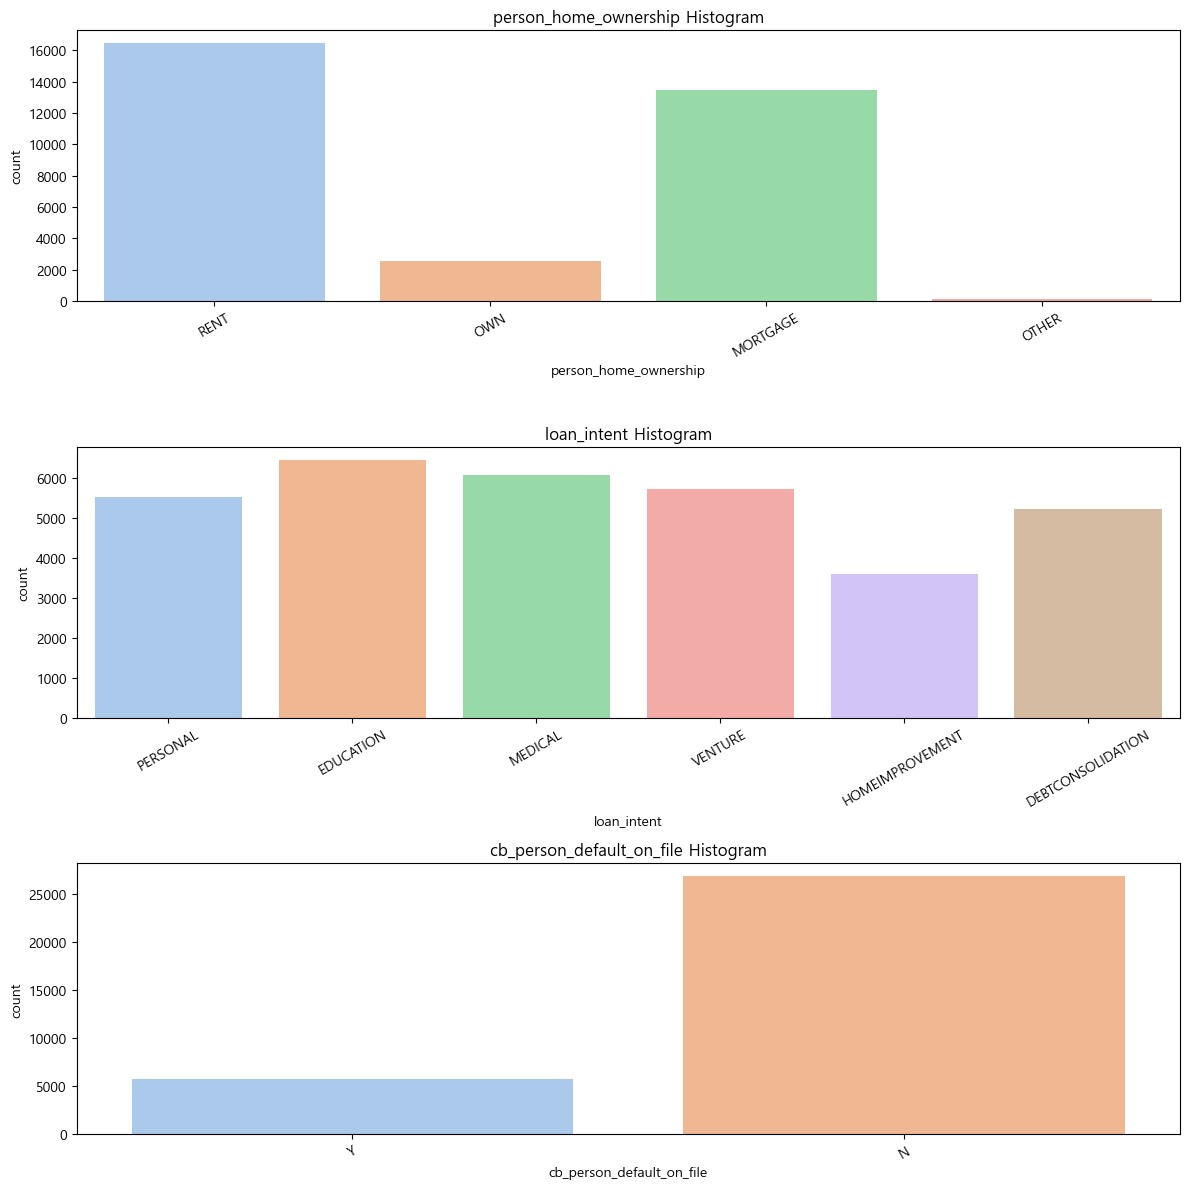

In [70]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))
axes = axes.flatten()

for i, col in enumerate(object_cols):
    sns.countplot(data=df, x=col, palette='pastel', ax=axes[i], hue=col)
    axes[i].set_title(f'{col} Histogram')
    axes[i].tick_params(axis='x', rotation=30)  # x축 라벨 겹침 방지용

plt.tight_layout()
plt.show()

In [48]:
object_cols = list(df.select_dtypes('object').columns)
object_cols.remove('loan_grade')  # y변수 제거 
object_cols

['person_home_ownership', 'loan_intent', 'cb_person_default_on_file']

In [61]:
# sns.countplot(data=df, x='cb_person_default_on_file', hue='loan_grade', palette='pastel')

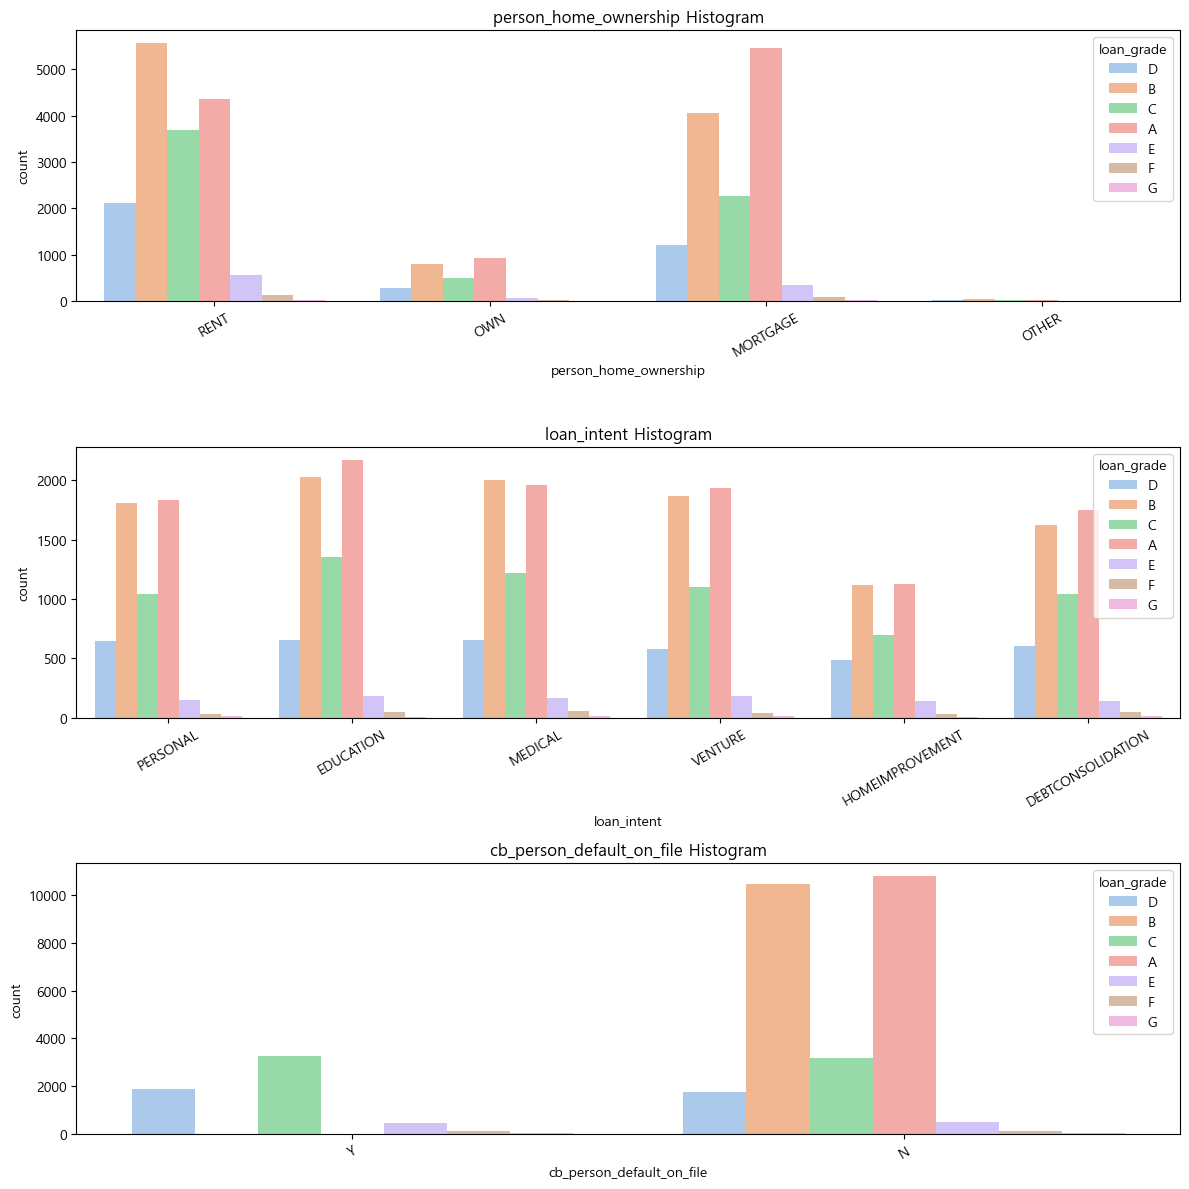

In [67]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))
axes = axes.flatten()

for i, col in enumerate(object_cols):
    sns.countplot(data=df, x=col, hue='loan_grade', palette='pastel', ax=axes[i])
    axes[i].set_title(f'{col} Histogram')
    axes[i].tick_params(axis='x', rotation=30)  # x축 라벨 겹침 방지용

plt.tight_layout()
plt.show()

#### X변수중에 수치형 데이터의 분포를 파악하기 

In [11]:
df.select_dtypes(['int', 'float']) 

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
0,22,59000,123.0,35000,16.02,1,0.59,3
1,21,9600,5.0,1000,11.14,0,0.10,2
2,25,9600,1.0,5500,12.87,1,0.57,3
3,23,65500,4.0,35000,15.23,1,0.53,2
4,24,54400,8.0,35000,14.27,1,0.55,4
...,...,...,...,...,...,...,...,...
32576,57,53000,1.0,5800,13.16,0,0.11,30
32577,54,120000,4.0,17625,7.49,0,0.15,19
32578,65,76000,3.0,35000,10.99,1,0.46,28
32579,56,150000,5.0,15000,11.48,0,0.10,26


In [12]:
cols = df.select_dtypes(['int', 'float']).columns

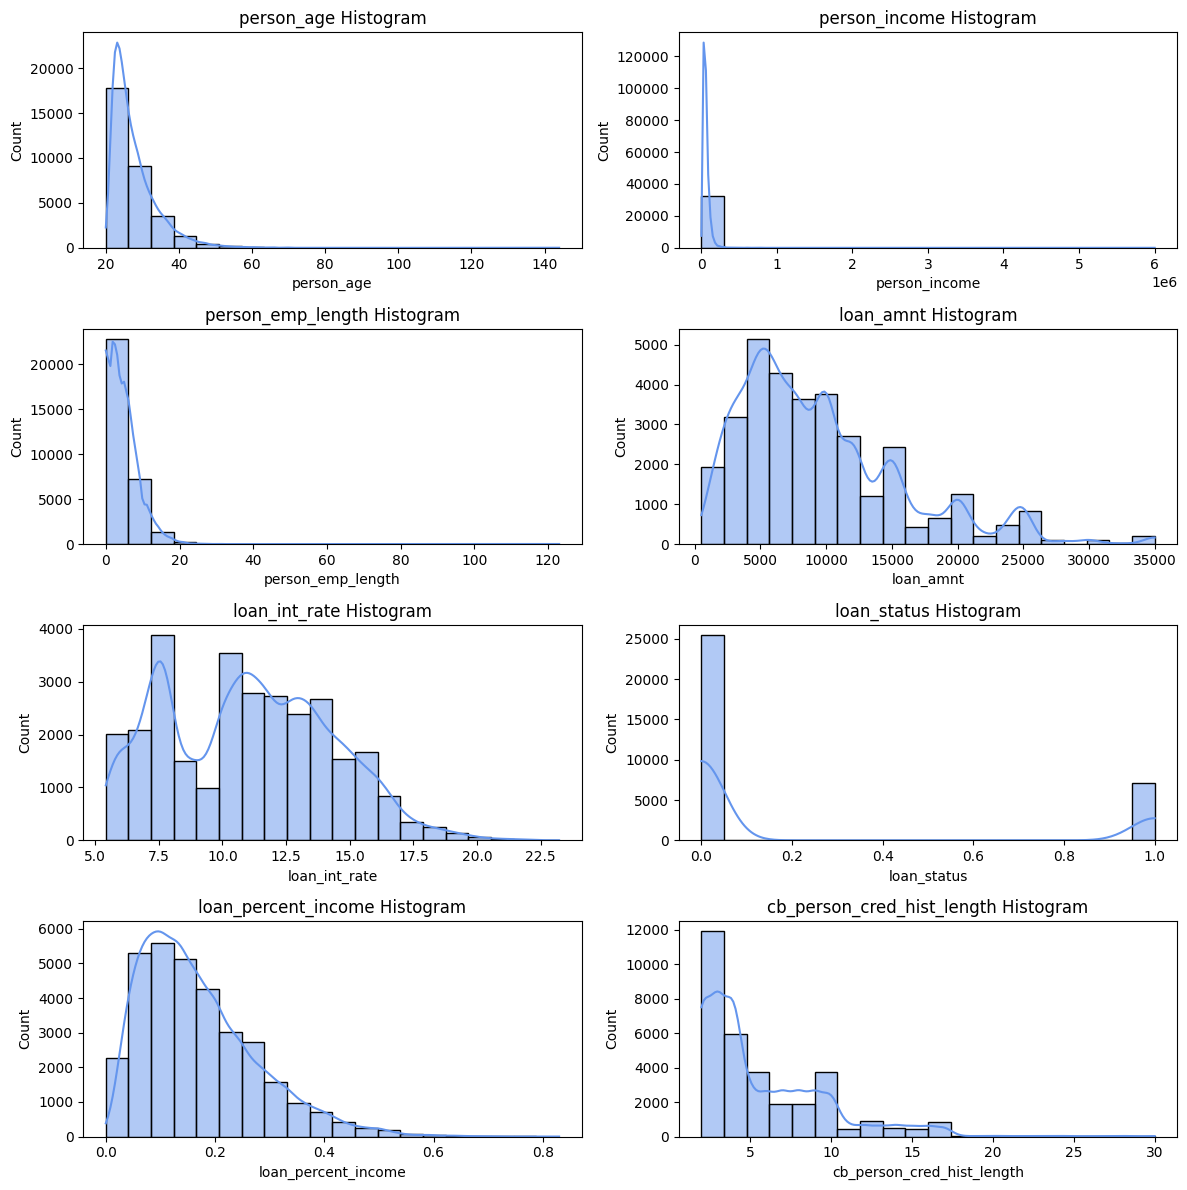

In [13]:
fig, axes = plt.subplots(4, 2, figsize=(12, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df[col], bins=20, kde=True, ax=axes[i], color='cornflowerblue')
    axes[i].set_title(f'{col} Histogram')

plt.tight_layout()
plt.show()

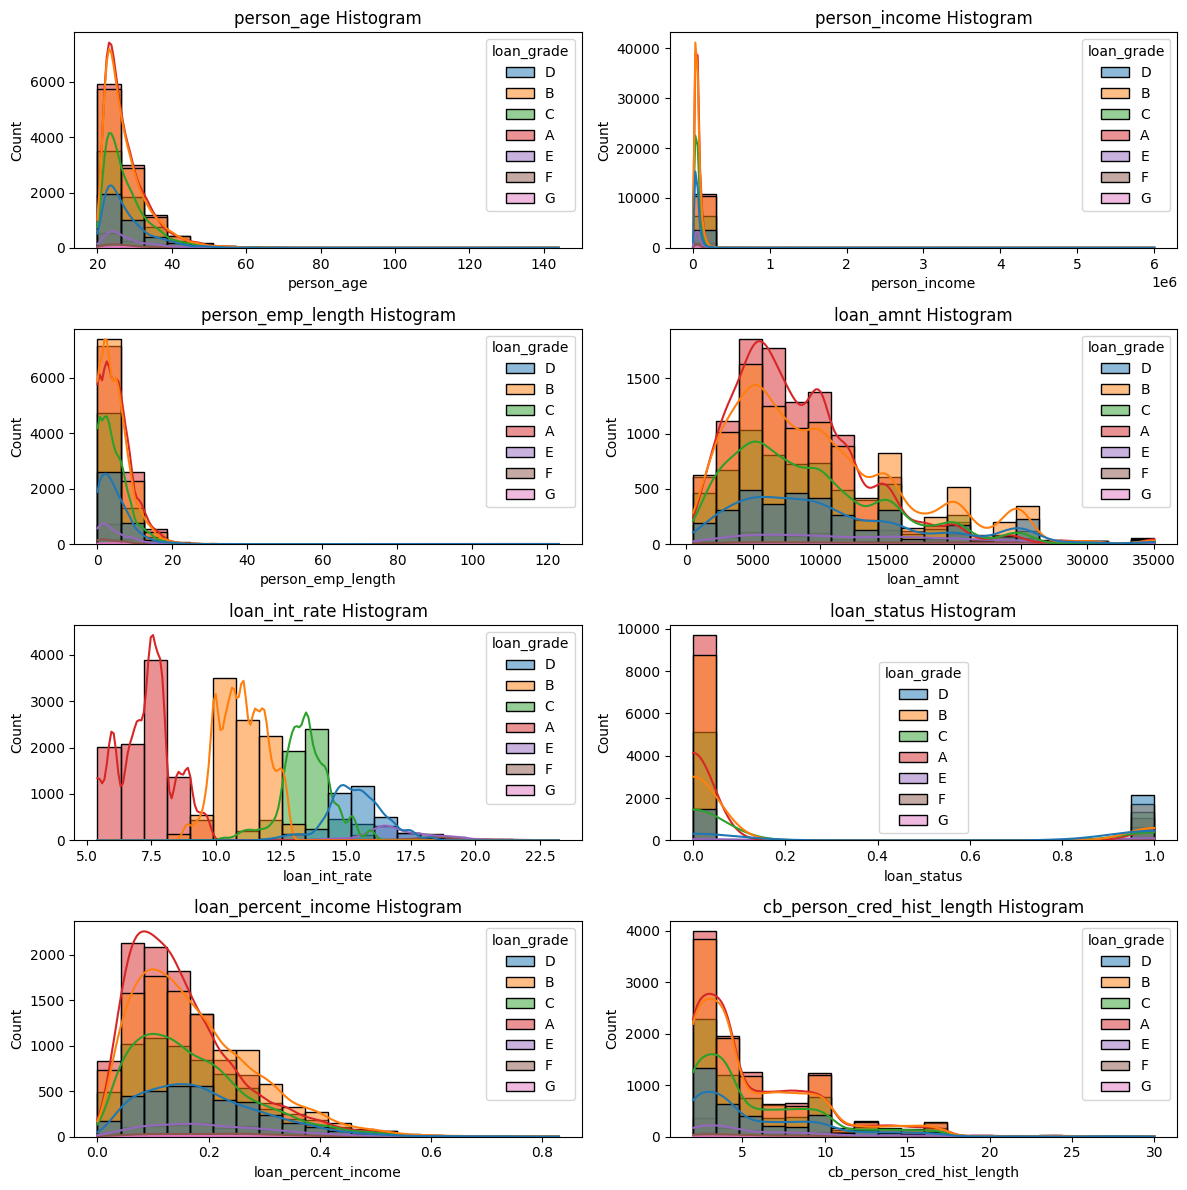

In [14]:
fig, axes = plt.subplots(4, 2, figsize=(12, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(data=df, x=col, hue='loan_grade', bins=20, kde=True, ax=axes[i], color='cornflowerblue')
    axes[i].set_title(f'{col} Histogram')

plt.tight_layout()
plt.show()

- 아래 시각화 결과 보니까 x변수에 노이즈를 추가해야겠다는 생각이 듦 

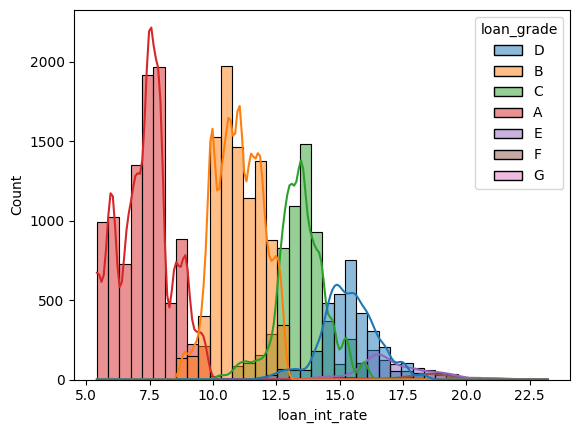

In [15]:
sns.histplot(data=df, x='loan_int_rate', hue='loan_grade', bins=40, kde=True, color='cornflowerblue')
plt.show()

In [23]:
# 노이즈 추가 테스트  
df['loan_int_rate_noise'] = df['loan_int_rate'] + np.random.uniform(low=-10, high=10, size=df.shape[0])

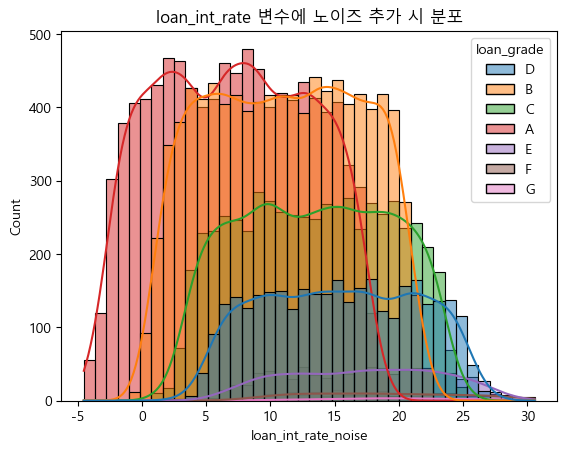

In [24]:
sns.histplot(data=df, x='loan_int_rate_noise', hue='loan_grade', bins=40, kde=True, color='cornflowerblue')
plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False
plt.title('loan_int_rate 변수에 노이즈 추가 시 분포')
plt.show()

In [25]:
df = df.drop(columns='loan_int_rate_noise')
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

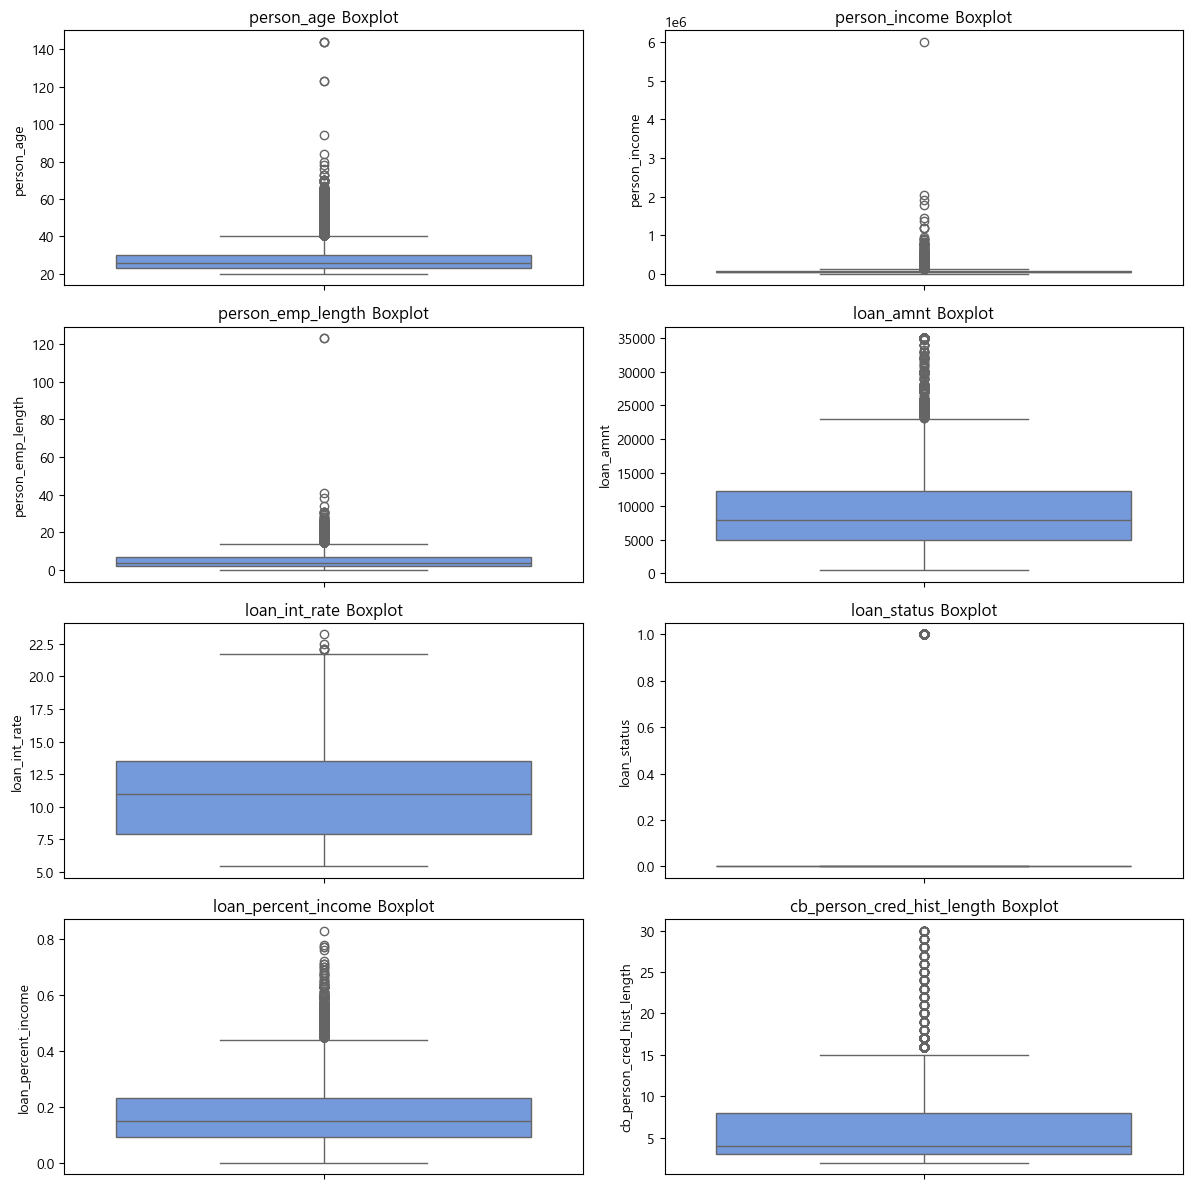

In [27]:
fig, axes = plt.subplots(4, 2, figsize=(12, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(data=df, y = col, ax=axes[i], color='cornflowerblue')
    axes[i].set_title(f'{col} Boxplot')

plt.tight_layout()
plt.show()

- loan_int_rate 변수가 너무 명확하게 분리되어 있음
- outlier 있는 변수들은 나중에 변경해줘야 하나?

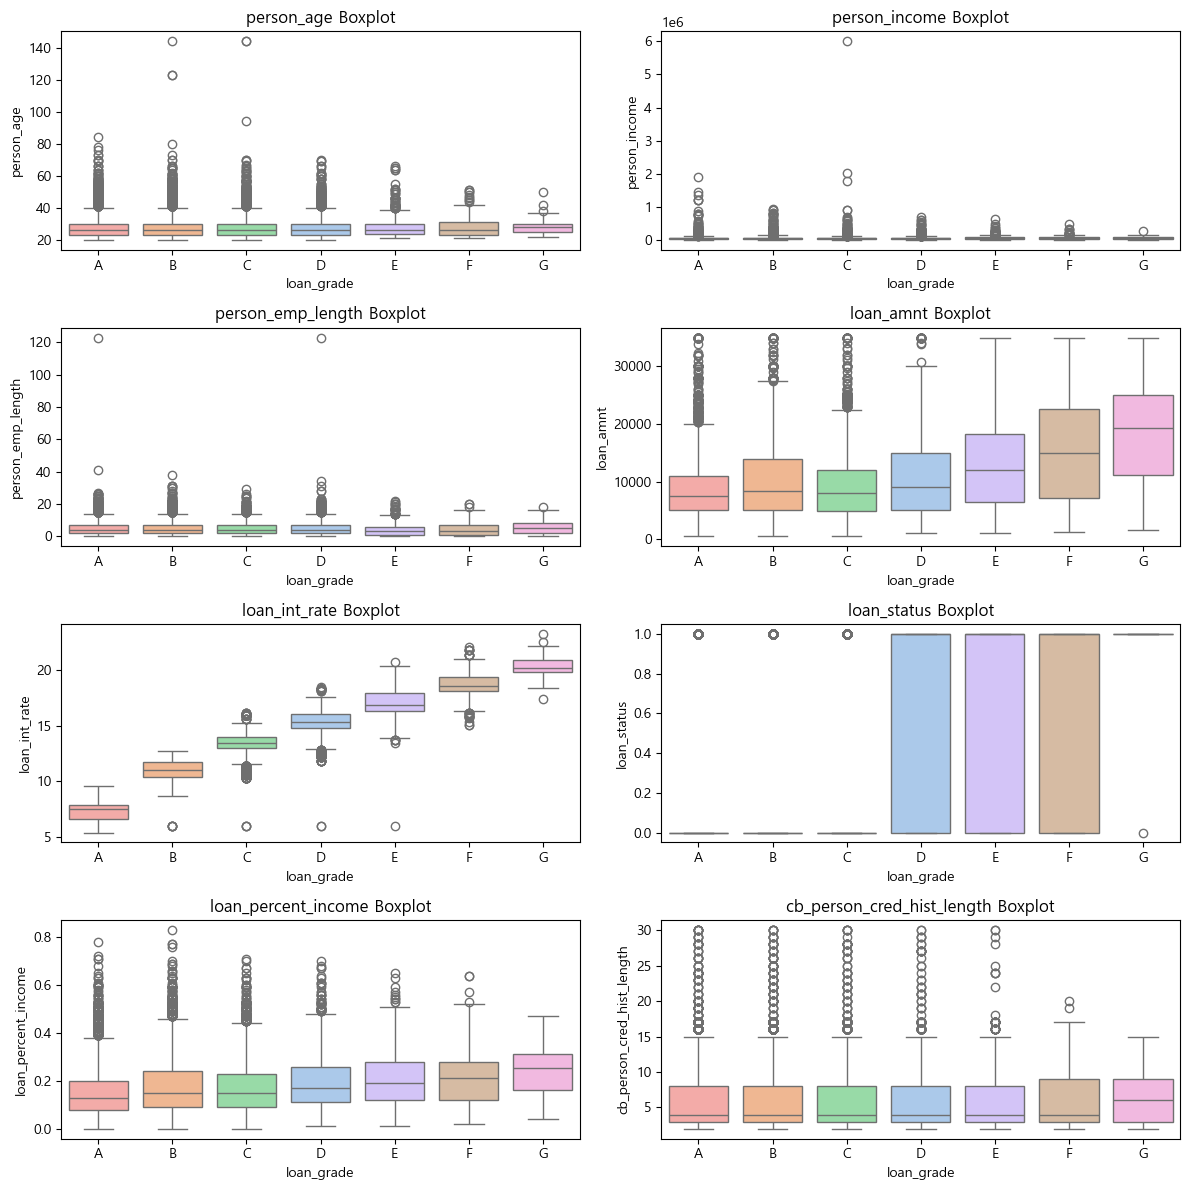

In [34]:
fig, axes = plt.subplots(4, 2, figsize=(12, 12))
axes = axes.flatten()
order = sorted(df['loan_grade'].unique())

for i, col in enumerate(cols):
    sns.boxplot(data=df, x='loan_grade', y=col, ax=axes[i], hue='loan_grade', palette='pastel', order=order)
    axes[i].set_title(f'{col} Boxplot')

plt.tight_layout()
plt.show()

#### 변수들 간의 관계 보기    
- 행렬식, 고유값, 상관행렬  